# Self-Consistency Sampling
## Temperature Scaling
### Understanding the process of selecting the next token

In [1]:
import torch
from mi.lm.model_loader import load_model_and_tokenizer
from mi.gpu import get_device

# device = get_device()
device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=True
)

✓ downloads/qwen3-0.6B-base.pth already up-to-date


In [2]:
from mi.generate import generate_text_stream_concat_flex

ex_prompt = "The capital of Germany is"

response = generate_text_stream_concat_flex(
    model, tokenizer, ex_prompt, device,
    max_new_tokens=1, verbose=True
)

 Berlin

In [3]:
input_token_ids = torch.tensor(
    tokenizer.encode(ex_prompt), device=device
).unsqueeze(0)
print(input_token_ids)

tensor([[ 785, 6722,  315, 9856,  374]])


In [4]:
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [5]:
max_token_id = torch.argmax(next_token_logits)
print(f"Token ID:      {max_token_id}")
print(f"Decoded token: '{tokenizer.decode([max_token_id])}'")

Token ID:      19846
Decoded token: ' Berlin'


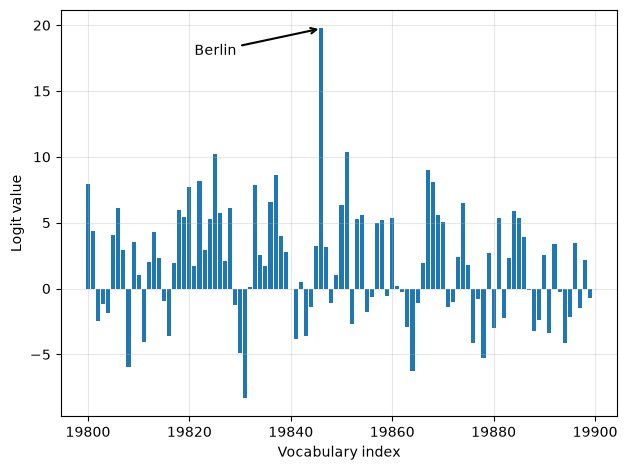

In [6]:
import matplotlib.pyplot as plt

def plot_scores_bar(
    next_token_logits, start=19_800, end=19_900,
    arrow=True, ylabel="Logit value"
):
    x = torch.arange(start, end)
    logits_section = next_token_logits[0, start:end].float().cpu()

    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)

    if arrow:  #4
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "Berlin",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={
                "facecolor": "black", "arrowstyle": "->", "lw": 1.5
            },
            fontsize=10,
        )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scores_bar(next_token_logits)

### Rescaling Token Scores via a Temperature Parameter

In [7]:
def scale_logits_by_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature


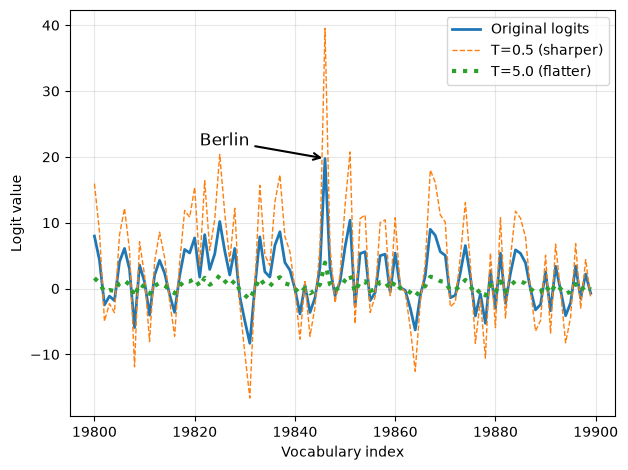

In [8]:
def plot_logits_with_temperature(
    next_token_logits, start=19_800, end=19_900,
    temps=(0.5, 5.0),
):
    x = torch.arange(start, end)
    logits_orig = next_token_logits[0, start:end].float().cpu()

    logits_scaled = [   #1
        scale_logits_by_temperature(logits_orig, T) for T in temps
    ]   #2

    plt.plot(x, logits_orig, label="Original logits", lw=2)
    plt.plot(
        x, logits_scaled[0],
        label=f"T={temps[0]} (sharper)", ls="--", lw=1
    )
    plt.plot(
        x, logits_scaled[1],
        label=f"T={temps[1]} (flatter)", ls=":", lw=3
    )

    # Highlight max logit
    max_idx = torch.argmax(logits_orig)
    plt.annotate(
        "Berlin",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )

    plt.xlabel("Vocabulary index")
    plt.ylabel("Logit value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_logits_with_temperature(
    next_token_logits,
    temps=(0.5, 5.0)                                        #5
)


### Convert rescaled logits into probability scores

In [9]:
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)

next_token_probas = torch.softmax(
    rescaled_logits, dim=-1
)

In [10]:
print("Probability sum:", torch.sum(next_token_probas))

Probability sum: tensor(1., dtype=torch.bfloat16)


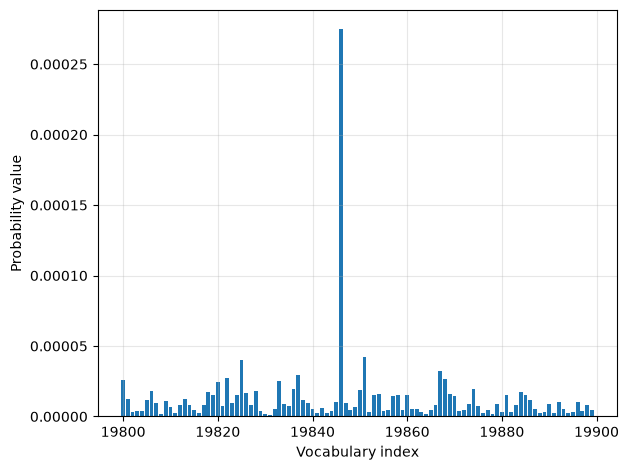

In [11]:
plot_scores_bar(next_token_probas, arrow=False, ylabel="Probability value")

In [12]:
print("Highest probability: ", max(next_token_probas.squeeze(0)))

Highest probability:  tensor(0.0003, dtype=torch.bfloat16)


In [13]:
def count_samples(probas, num_samples=1000, threshold=1, tokenizer=None):
    samples = torch.multinomial(
        probas.cpu(), num_samples=num_samples, replacement=True
    )
    counts = torch.bincount(samples.squeeze(0), minlength=1)

    for i, c in enumerate(counts):
        if c > threshold:
            if tokenizer is None:
                print(f"Vocab index {i}: {c.item()}x")
            else:
                print(f"'{tokenizer.decode([i])}': {c.item()}x")


In [14]:
count_samples(next_token_probas, tokenizer=tokenizer)

' test': 2x
' Ref': 2x
' }


': 2x
' aden': 2x


In [15]:
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, tokenizer=tokenizer)

'
': 3x
' __': 128x
' ___': 2x
' Berlin': 420x
' ____': 209x
' ______': 199x
' Munich': 4x
' Hamburg': 5x
' _____': 28x


### Add temperature scaling to the text generation function

In [19]:
from mi.generate import generate_text_temp_stream_cache
from mi.eval import render_prompt

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)

prompt = render_prompt(raw_prompt)

# torch.manual_seed(123)

response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1
)

 To solve the equation where half the value of \(3x - 9\) is \(x + 37\), follow these steps:

1. **Set up the equation:**
   
   \[
   \frac{3x - 9}{2} = x + 37
   \]

2. **Eliminate the fraction by multiplying both sides by 2:**
   
   \[
   3x - 9 = 2(x + 37)
   \]

3. **Expand the right side of the equation:**
   
   \[
   3x - 9 = 2x + 74
   \]

4. **Subtract \(2x\) from both sides to get the \(x\) terms on one side:**
   
   \[
   3x - 2x - 9 = 74
   \]
   
   \[
   x - 9 = 74
   \]

5. **Add 9 to both sides to solve for \(x\):**
   
   \[
   x = 74 + 9
   \]
   
   \[
   x = 83
   \]

6. **Final Answer:**
   
   \[
   \boxed{83}
   \]

## Top-p Sampling
Balances diversity and coherence